# Optimización multi-activo con cripto: capítulo 3

## Riesgo de cola y optimización CVaR sobre el baseline multi-activo

### Resumen ejecutivo

Este capítulo evalúa, bajo **comparación justa**, si sustituir MinVar por un objetivo de cola (CVaR histórico) cambia materialmente el perfil downside realizado de la cartera. La evidencia OOS del periodo común sugiere una lectura prudente: en esta muestra, CVaR no domina de forma robusta a MinVar en cola/drawdown, introduce algo más de rotación y mantiene un uso de cripto más activo pero no estructural.

El objetivo no es “probar un ganador”, sino mapear **trade-offs de construcción de cartera** entre protección de cola, retorno, fricción operativa y net-of-cost performance.

---
## 1 - Pregunta de investigación

**¿Bajo el mismo protocolo OOS y las mismas restricciones que MinVar, una cartera *minimum-CVaR* mejora el control de *downside / drawdown / tail risk*, y a qué coste en retorno, turnover y uso de cripto?**

La pregunta es deliberadamente diagnóstica. No se trata de demostrar que CVaR "gana" a MinVar ni de proponer una estrategia ganadora: se trata de medir si **cambiar el objetivo de optimización desde varianza a cola altera materialmente el perfil downside realizado**, manteniendo todo lo demás constante.

**Evidencia que se presentará.** Métricas OOS en bruto y netas de costes (retorno, vol, Sharpe, MaxDD, Calmar, ES95, Ret/ES, turnover) sobre el tramo común; trayectoria de riqueza y drawdown comparados; tres ventanas de estrés histórico; dinámica de pesos y uso del *sleeve* cripto.

**Límite de inferencia.** El análisis es **descriptivo**, sobre una sola muestra OOS, un universo fijo y una formulación concreta de CVaR (histórico, $\beta = 0.95$, lookback 252 d). No hay tests inferenciales en este capítulo, no hay regímenes, supervised ML ni overlays. Las conclusiones se leen como evidencia condicional, no como verdad universal sobre minimum-CVaR.

### Qué hace y qué no hace este capítulo

| Hace | No hace |
|---|---|
| Compara MinVar vs CVaR bajo mismo tramo OOS, restricciones y costes. | No reestima el pipeline ni introduce modelos nuevos. |
| Evalúa cola y downside con ES95, MaxDD y métricas complementarias. | No prueba causalidad ni superioridad universal de CVaR. |
| Contrasta bruto vs neto para cuantificar fricción sistemática. | No modela slippage/impacto/capacidad de forma completa. |
| Usa ventanas históricas de estrés como diagnóstico condicional. | No sustituye un análisis formal por regímenes. |
| Revisa el uso efectivo del sleeve cripto y controles sin crypto. | No demuestra que cripto diversifique de forma estable en crisis. |

### Cómo leer este capítulo

1. Primero, leer §2-§3 como marco metodológico: qué se mantiene fijo y qué se está testeando realmente.
2. Luego, leer §4-§5 para la evidencia de cola realizada (no para confirmar teoría ex ante).
3. Después, leer §6-§7 para traducir rendimiento a implementabilidad neta de costes.
4. Usar §8-§9 para separar evidencia agregada de comportamiento por episodio y uso efectivo de cripto.
5. Cerrar en §10-§13 distinguiendo: diferencia descriptiva, relevancia económica y conclusión sostenible.

---
## 2 - Protocolo de comparación justa

La validez de la lectura depende íntegramente de que la única fuente de variación entre MinVar y CVaR sea la **función objetivo**. Todo lo demás se mantiene fijo.

| Dimensión | Valor común a las cuatro estrategias |
|---|---|
| Universo de activos | Mismo *sleeve* multi-activo del Capítulo 1 |
| Restricciones | Solo posiciones largas, $\sum_i w_i = 1$, $w_i \le 0{,}35$, $w_{\text{BTC}} + w_{\text{ETH}} \le 0{,}20$ (relajado a 0 en los controles *sin crypto*) |
| Lookback de estimación | 252 días hábiles |
| Frecuencia de rebalanceo | Mensual |
| Tramo OOS | Común a las cuatro estrategias (impreso en la celda de validación) |
| Modelo de costes | 10 bps unidireccionales sobre turnover realizado |
| Parámetro de cola (CVaR) | $\beta = 0{,}95$ |

La única diferencia entre familias es la función objetivo: $\min_w w^\top \hat\Sigma w$ para MinVar frente a la formulación lineal de Rockafellar-Uryasev (2000) para minimum-CVaR sobre la muestra histórica de la ventana. La diferencia entre baseline y control dentro de cada familia es exclusivamente el tope cripto. Cualquier diferencia OOS en métricas se atribuye, por construcción, a una de esas dos palancas.

**Evidencia que se presentará.** La celda de validación confirma que las cuatro estrategias comparten exactamente las mismas fechas OOS y el mismo número de rebalances, condición necesaria para que las diferencias sean comparables.

**Límite de inferencia.** Un protocolo común no produce significancia estadística por sí solo: garantiza ausencia de sesgo de selección entre estrategias, no robustez muestral. La pregunta de cuánta de la diferencia observada es señal y cuánta es ruido queda fuera del alcance de este capítulo.

---
## 3 - Por qué CVaR después de MinVar

MinVar minimiza varianza condicional al estimador $\hat\Sigma$, una medida simétrica que no distingue entre desviaciones favorables y desfavorables. En carteras con activos de cola gruesa o asimétrica -cripto, en este universo-, dos críticas habituales se aplican:

1. **Asimetría.** La varianza penaliza por igual la cola derecha y la izquierda; un inversor con aversión a pérdidas grandes preferiría un objetivo que actúe directamente sobre la cola izquierda.
2. **No coherencia del VaR.** El Value-at-Risk fue criticado por no ser una medida de riesgo coherente (Artzner et al., 1999). El **Expected Shortfall / CVaR** sí lo es (Acerbi y Tasche, 2002): es subaditivo, traduce escenarios de cola en un promedio condicional y admite una formulación de optimización lineal tratable (Rockafellar y Uryasev, 2000).

### Anclas metodológicas del capítulo

- **Markowitz / mean-variance** es el punto de partida conceptual de la construcción de cartera moderna.
- **MinVar** funciona como baseline risk-based robusto en práctica porque evita estimar retornos esperados y concentra la decisión en riesgo/covarianza.
- **CVaR histórico** traslada explícitamente el objetivo a pérdidas de cola (Expected Shortfall), pero su desempeño OOS depende de error de estimación y estabilidad de la muestra.
- Con $\beta = 0.95$ y lookback de 252 días, el número efectivo de observaciones en cola es bajo; eso puede volver el objetivo **muestralmente frágil** y elevar rotación.
- **Costes y turnover** no son un apéndice: son condición de implementabilidad. Por eso la lectura bruto vs neto es central, no secundaria.
- **Ventanas de estrés** agregan contexto económico por episodio, pero siguen siendo evidencia condicional, no prueba universal.

La predicción razonable, por tanto, sería: bajo retornos no gaussianos, **minimum-CVaR debería producir un perfil downside mejor que MinVar**, posiblemente al coste de algo de retorno o de mayor turnover.

Hay sin embargo dos contrapesos teóricos importantes que el capítulo no puede ignorar:

- **Equivalencia bajo retornos elípticos.** Si los retornos son aproximadamente elípticos, MinVar y MinCVaR comparten la misma frontera eficiente (Embrechts, McNeil y Frey, 2015). En ese régimen, cualquier diferencia OOS sería atribuible a estimación, no a estructura.
- **Fragilidad muestral del CVaR empírico.** Con $\beta = 0{,}95$ y un lookback de 252 días, solo unas ~13 observaciones entran en el promedio de cola que define la función objetivo. Lim, Shanthikumar y Vahn (2011) muestran que esto introduce error de estimación significativo y puede deteriorar desempeño OOS incluso en métricas de cola.

**Cómo se interpreta CVaR en este capítulo.** Como **objetivo de riesgo de cola**, no como señal de retorno. La salida del optimizador es un peso, no un pronóstico. La métrica relevante para juzgarlo es el ES realizado *out-of-sample*, no el ES *in-sample* que minimiza por construcción.

**Evidencia que se presentará.** Las secciones siguientes contrastan, sobre el mismo tramo OOS, si la mejora teóricamente esperable se materializa en ES, MaxDD y Calmar realizados, y a qué coste lo hace.

**Límite de inferencia.** Las anclas teóricas anteriores son referencias de literatura, no garantías sobre esta muestra. Una sola formulación de CVaR (histórica empírica, $\beta = 0{,}95$, lookback 252 d) sobre un solo universo y un solo OOS no permite generalizar a otras parametrizaciones del mismo objetivo, ni mucho menos a otras medidas de cola.

In [9]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.dates as mdates  # noqa: F401  (reservado para fase analítica)
import matplotlib.pyplot as plt
import numpy as np  # noqa: F401
import pandas as pd
from matplotlib.ticker import PercentFormatter  # noqa: F401

warnings.filterwarnings("ignore")

# Paths anclados en la raíz del repo (no se exponen rutas locales en outputs).
PROJECT_ROOT = Path("..").resolve()
TAIL_DIR = PROJECT_ROOT / "data" / "processed" / "tail_risk"

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# Paleta consistente entre familias y entre baseline/control.
# - Familia: color (MinVar = azul; CVaR = granate).
# - Variante: estilo de línea / saturación (baseline = sólido; sin cripto = guion / tono claro).
STYLE = {
    "minvar_baseline_ch1":      {"color": "#1f4e79", "linestyle": "-",  "marker": "o"},
    "minvar_no_crypto_control": {"color": "#6c8ebf", "linestyle": "--", "marker": "s"},
    "cvar_baseline":            {"color": "#9e2a2b", "linestyle": "-",  "marker": "o"},
    "cvar_no_crypto_control":   {"color": "#c98a8b", "linestyle": "--", "marker": "s"},
}

In [10]:
# Capa de etiquetas humanas. No modifica los CSV; sólo presentación.
DISPLAY_NAMES: dict[str, str] = {
    "minvar_baseline_ch1":      "MinVar (baseline)",
    "minvar_no_crypto_control": "MinVar (sin crypto)",
    "cvar_baseline":            "CVaR (baseline)",
    "cvar_no_crypto_control":   "CVaR (sin crypto)",
}

FAMILY_OF: dict[str, str] = {
    "minvar_baseline_ch1":      "MinVar",
    "minvar_no_crypto_control": "MinVar",
    "cvar_baseline":            "CVaR",
    "cvar_no_crypto_control":   "CVaR",
}

VARIANT_OF: dict[str, str] = {
    "minvar_baseline_ch1":      "baseline",
    "minvar_no_crypto_control": "sin crypto",
    "cvar_baseline":            "baseline",
    "cvar_no_crypto_control":   "sin crypto",
}

# Orden canónico para tablas y figuras: primero MinVar, luego CVaR; baseline antes que control.
STRATEGY_ORDER: list[str] = [
    "minvar_baseline_ch1",
    "minvar_no_crypto_control",
    "cvar_baseline",
    "cvar_no_crypto_control",
]

def label(strategy_id: str) -> str:
    """Display name humano; fallback al id si no está mapeado."""
    return DISPLAY_NAMES.get(strategy_id, strategy_id)

def family_of(strategy_id: str) -> str:
    return FAMILY_OF.get(strategy_id, "?")

def variant_of(strategy_id: str) -> str:
    return VARIANT_OF.get(strategy_id, "?")

def style_of(strategy_id: str) -> dict:
    return STYLE.get(strategy_id, {"color": "#444", "linestyle": "-", "marker": "o"})

def humanize(df: pd.DataFrame, col: str = "strategy") -> pd.DataFrame:
    """Devuelve copia de df con columnas auxiliares (familia, variante, display).
    No reemplaza la columna original para preservar joins por id técnico."""
    out = df.copy()
    if col in out.columns:
        out["family"]  = out[col].map(family_of)
        out["variant"] = out[col].map(variant_of)
        out["display"] = out[col].map(label)
    return out

In [11]:
# Helpers de carga y formato.
def load_csv(path: Path, parse_dates: list[str] | None = None) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path.name}")
    return pd.read_csv(path, parse_dates=parse_dates)

def assert_strategies(df: pd.DataFrame, name: str) -> None:
    found = set(df["strategy"].unique()) if "strategy" in df.columns else set()
    missing = [s for s in STRATEGY_ORDER if s not in found]
    if missing:
        raise ValueError(f"{name}: faltan estrategias esperadas: {missing}")

def metric_table(df: pd.DataFrame, *, net: bool = False) -> pd.DataFrame:
    """Tabla compacta con etiquetas humanas y formato consistente.
    Se usará en la fase analítica; aquí queda sólo definida."""
    suffix = "_net" if net else ""
    cols_map = {
        f"ann_return{suffix}":       "Retorno anual.",
        f"ann_volatility{suffix}":   "Vol. anual.",
        f"sharpe{suffix}":           "Sharpe",
        f"max_drawdown{suffix}":     "MaxDD",
        f"calmar{suffix}":           "Calmar",
        f"expected_shortfall{suffix}": "ES95 (diario)",
        f"return_over_es{suffix}":   "Ret/ES",
        "mean_turnover":             "Turnover medio",
    }
    keep = [c for c in cols_map if c in df.columns]
    if "strategy" not in df.columns:
        raise ValueError("metric_table espera columna 'strategy'")
    out = df.set_index("strategy").loc[
        [s for s in STRATEGY_ORDER if s in df["strategy"].values], keep
    ].rename(columns=cols_map)
    out.index = out.index.map(label)
    out.index.name = "Estrategia"
    pct_cols = ["Retorno anual.", "Vol. anual.", "MaxDD", "ES95 (diario)", "Turnover medio"]
    for c in pct_cols:
        if c in out.columns:
            out[c] = out[c].map(lambda v: f"{v*100:.2f}%")
    for c in ["Sharpe", "Calmar", "Ret/ES"]:
        if c in out.columns:
            out[c] = out[c].map(lambda v: f"{v:.3f}")
    return out

In [12]:
# Carga y validación silenciosa de los seis outputs de Capítulo 3.
summary_gross = load_csv(TAIL_DIR / "tail_risk_summary.csv")
summary_net   = load_csv(TAIL_DIR / "tail_risk_summary_net.csv")
returns_long  = load_csv(TAIL_DIR / "tail_risk_returns.csv",        parse_dates=["date"])
weights_long  = load_csv(TAIL_DIR / "tail_risk_weights_panel.csv",  parse_dates=["rebalance_date"])
turnover_long = load_csv(TAIL_DIR / "tail_risk_turnover_panel.csv", parse_dates=["rebalance_date"])
stress_long   = load_csv(TAIL_DIR / "stress_summary.csv",           parse_dates=["start_date", "end_date"])

for name, df in [
    ("summary_gross", summary_gross),
    ("summary_net",   summary_net),
    ("returns_long",  returns_long),
    ("weights_long",  weights_long),
    ("turnover_long", turnover_long),
    ("stress_long",   stress_long),
]:
    assert_strategies(df, name)

# Chequeo de alineamiento OOS (mismo tramo, mismo n_oos_days, mismo número de rebalances).
oos_check = (
    summary_gross[["strategy", "oos_start", "oos_end", "n_oos_days", "n_rebalances"]]
    .drop_duplicates()
)
if oos_check[["oos_start", "oos_end", "n_oos_days", "n_rebalances"]].nunique().max() != 1:
    raise ValueError("OOS no alineado entre estrategias en summary_gross")

OOS_START = pd.to_datetime(oos_check["oos_start"].iloc[0]).date()
OOS_END   = pd.to_datetime(oos_check["oos_end"].iloc[0]).date()
N_OOS     = int(oos_check["n_oos_days"].iloc[0])
N_REBAL   = int(oos_check["n_rebalances"].iloc[0])

print(f"OOS común: {OOS_START} → {OOS_END}  |  n_oos_days = {N_OOS}  |  rebalances = {N_REBAL}")
print(f"Estrategias cargadas: {len(STRATEGY_ORDER)}  |  ventanas de stress: {stress_long['window_id'].nunique()}")

OOS común: 2018-10-01 → 2026-05-02  |  n_oos_days = 2771  |  rebalances = 92
Estrategias cargadas: 4  |  ventanas de stress: 3


---
## 4 - Resultados OOS principales

Esta sección fija el punto de partida cuantitativo del capítulo: las métricas OOS realizadas por las cuatro estrategias sobre el tramo común validado en el setup. Sirve como referencia para el resto de bloques: el análisis de cola en §5, la lectura neta de costes en §6, la implementabilidad en §7, las ventanas históricas de estrés en §8 y la dinámica del sleeve cripto en §9.

**Convenciones que se aplicarán de aquí en adelante.**

- ES95 (Expected Shortfall) está expresado como **pérdida diaria positiva** (promedio de pérdidas en el peor 5% de la cola). Por construcción, **menor ES95 implica mejor control de cola**.
- MaxDD se reporta con su signo nativo (negativo); se usará `|MaxDD|` cuando se compare magnitud entre estrategias.
- Todos los rankings de esta sección son sobre métricas **brutas**; la lectura neta de costes se aborda específicamente en §6.


In [32]:
# Tabla compacta de resultados OOS en bruto (principal).
headline_cols = [
    "strategy",
    "ann_return",
    "ann_volatility",
    "sharpe",
    "max_drawdown",
    "calmar",
    "expected_shortfall",
    "return_over_es",
    "mean_turnover",
]

headline = (
    summary_gross[headline_cols]
    .set_index("strategy")
    .loc[[s for s in STRATEGY_ORDER if s in summary_gross["strategy"].values]]
    .rename(index=DISPLAY_NAMES)
)

fmt = headline.copy()
for c in ["ann_return", "ann_volatility", "max_drawdown", "expected_shortfall", "mean_turnover"]:
    fmt[c] = fmt[c].map(lambda v: f"{v*100:.2f}%")
for c in ["sharpe", "calmar", "return_over_es"]:
    fmt[c] = fmt[c].map(lambda v: f"{v:.3f}")

fmt = fmt.rename(
    columns={
        "ann_return": "Ret anual",
        "ann_volatility": "Vol anual",
        "sharpe": "Sharpe",
        "max_drawdown": "MaxDD",
        "calmar": "Calmar",
        "expected_shortfall": "ES95 diario",
        "return_over_es": "Ret/ES",
        "mean_turnover": "Turnover medio",
    }
)

display(fmt)

rank_ret = summary_gross.sort_values("ann_return", ascending=False)[["strategy", "ann_return"]].copy()
rank_ret["strategy"] = rank_ret["strategy"].map(DISPLAY_NAMES)
rank_es = summary_gross.sort_values("expected_shortfall", ascending=True)[["strategy", "expected_shortfall"]].copy()
rank_es["strategy"] = rank_es["strategy"].map(DISPLAY_NAMES)

print("Ranking por retorno anual (bruto):")
print(rank_ret.to_string(index=False))
print("\nRanking por ES95 diario (menor es mejor, bruto):")
print(rank_es.to_string(index=False))

,Ret anual,Vol anual,Sharpe,MaxDD,Calmar,ES95 diario,Ret/ES,Turnover medio
strategy,,,,,,,,
MinVar (baseline),8.32%,8.94%,0.930,-23.33%,0.356,1.34%,6.218,3.16%
MinVar (sin crypto),8.19%,8.90%,0.921,-23.34%,0.351,1.33%,6.138,2.91%
CVaR (baseline),8.03%,9.14%,0.879,-23.98%,0.335,1.38%,5.824,4.04%
CVaR (sin crypto),8.11%,9.04%,0.896,-23.98%,0.338,1.37%,5.925,3.56%


Ranking por retorno anual (bruto):
           strategy  ann_return
  MinVar (baseline)    0.083176
MinVar (sin crypto)    0.081922
  CVaR (sin crypto)    0.081065
    CVaR (baseline)    0.080349

Ranking por ES95 diario (menor es mejor, bruto):
           strategy  expected_shortfall
MinVar (sin crypto)            0.013348
  MinVar (baseline)            0.013376
  CVaR (sin crypto)            0.013683
    CVaR (baseline)            0.013795


Lectura económica (§4, resultados agregados en bruto):

- En este tramo OOS, MinVar (baseline) conserva mejor retorno y Sharpe frente a CVaR (baseline), por lo que no aparece dominancia directa de CVaR en el plano agregado.
- En este capítulo, la lectura principal de downside debe priorizar **ES95, MaxDD y Ret/ES** por encima de Sharpe: la pregunta no es maximizar eficiencia media, sino evaluar cola realizada.
- El hecho de que CVaR optimice pérdidas históricas in-sample no garantiza una mejora de ES95 out-of-sample; con muestra de cola corta, el error de estimación puede revertir parte de la ventaja esperada.
- Las diferencias observadas son económicamente acotadas y no deben sobreactuarse: el resultado defendible es de cambio de perfil con trade-offs, no de superioridad estructural.

Esta sección fija la base descriptiva; la validación económica exige leerla junto con costes netos (§6) y carga operativa (§7).

---
## 5 - Downside, drawdown y riesgo de cola

Bajo la motivación teórica de §3, la pregunta operativa es directa: **¿se materializa la mejora de cola que CVaR debería producir bajo retornos no gaussianos?** La sección se mantiene deliberadamente compacta y solo presenta dos piezas suficientes para responder antes de pasar a la lectura neta de costes:

1. Trayectoria del drawdown acumulado OOS por estrategia.
2. Comparación puntual de MaxDD y ES95 diario sobre el tramo común.

La lectura es descriptiva: si CVaR no domina aquí en bruto, difícilmente lo hará en neto de costes. Si domina, la pregunta pasa a si esa ventaja sobrevive a costes y turnover (§6 y §7).


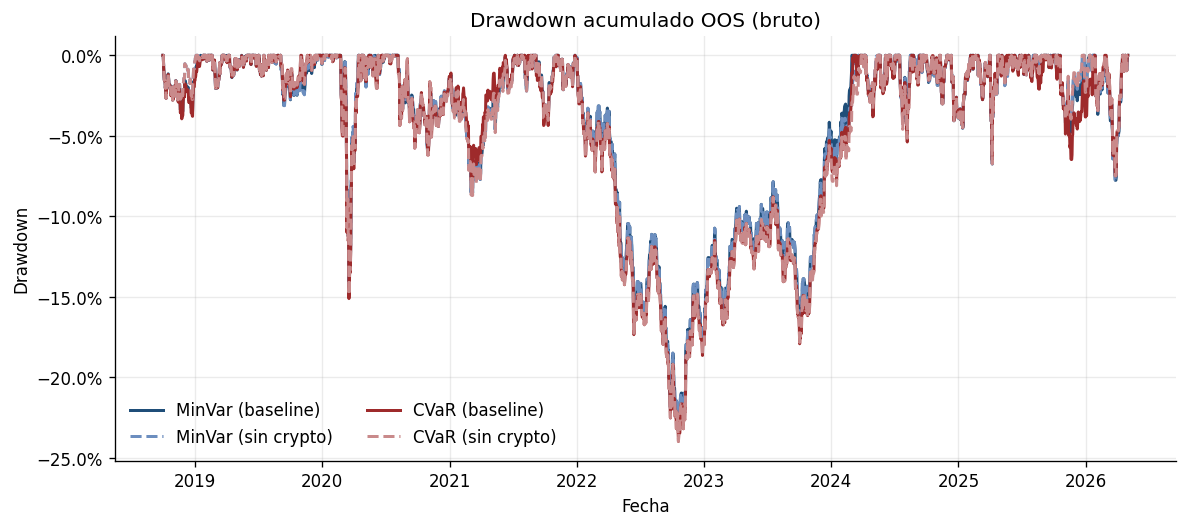

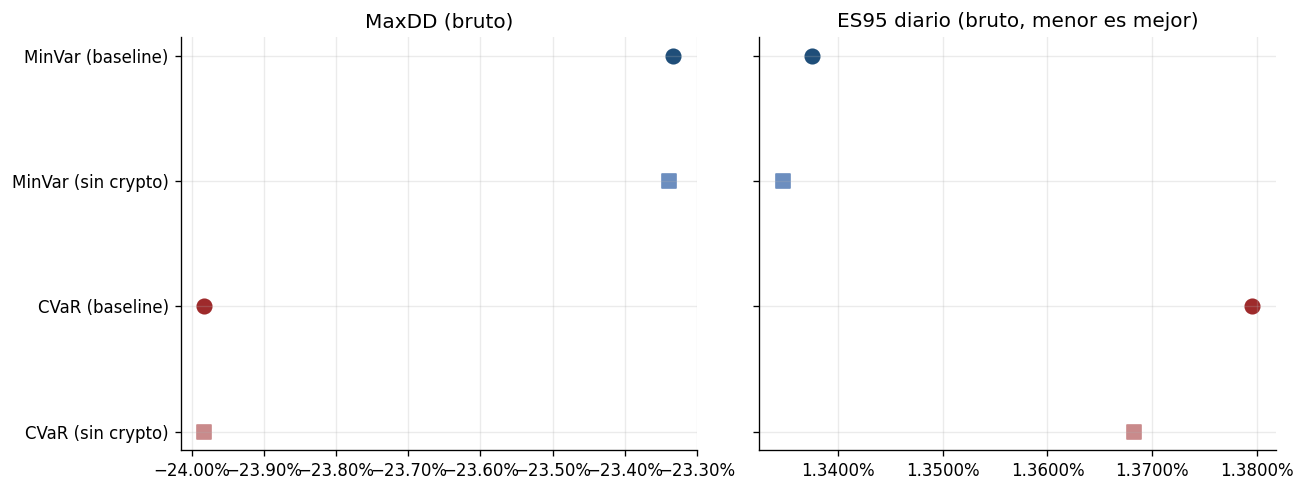

In [39]:
# 5.1 Drawdown OOS por estrategia (bruto).
ret = returns_long.copy()
ret = ret[ret["strategy"].isin(STRATEGY_ORDER)].copy()
ret = ret.sort_values(["strategy", "date"])

if "return" in ret.columns:
    daily_ret_col = "return"
elif "daily_return" in ret.columns:
    daily_ret_col = "daily_return"
elif "portfolio_return" in ret.columns:
    daily_ret_col = "portfolio_return"
else:
    raise ValueError("No se encuentra columna de retorno diario en tail_risk_returns.csv")

ret["wealth"] = ret.groupby("strategy")[daily_ret_col].transform(lambda x: (1.0 + x).cumprod())
ret["peak"] = ret.groupby("strategy")["wealth"].transform(lambda x: x.cummax())
ret["drawdown"] = ret["wealth"] / ret["peak"] - 1.0

fig, ax = plt.subplots(figsize=(10, 4.5))
for sid in STRATEGY_ORDER:
    d = ret[ret["strategy"] == sid]
    st = style_of(sid)
    ax.plot(d["date"], d["drawdown"], label=label(sid), color=st["color"], linestyle=st["linestyle"], lw=1.8)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Drawdown acumulado OOS (bruto)")
ax.set_ylabel("Drawdown")
ax.set_xlabel("Fecha")
ax.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

# 5.2 Dot plot de cola: MaxDD y ES95 (bruto).
comp = summary_gross[["strategy", "max_drawdown", "expected_shortfall"]].copy()
comp["display"] = comp["strategy"].map(label)
comp = comp.set_index("strategy").loc[STRATEGY_ORDER].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
y = np.arange(len(comp))

for i, sid in enumerate(comp["strategy"]):
    st = style_of(sid)
    axes[0].scatter(comp.loc[i, "max_drawdown"], y[i], s=75, color=st["color"], marker=st["marker"])
    axes[1].scatter(comp.loc[i, "expected_shortfall"], y[i], s=75, color=st["color"], marker=st["marker"])

axes[0].set_title("MaxDD (bruto)")
axes[1].set_title("ES95 diario (bruto, menor es mejor)")
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].set_yticks(y)
axes[0].set_yticklabels(comp["display"])
axes[0].invert_yaxis()
axes[1].tick_params(axis="y", labelleft=False)
plt.tight_layout()
plt.show()

Lectura de downside y riesgo de cola (§5):

- El drawdown acumulado muestra trayectorias cercanas entre familias; no emerge una separación estructural fuerte atribuible únicamente al cambio de objetivo.
- En esta muestra, CVaR no domina de forma robusta en ES95 ni en MaxDD frente a MinVar, pese a estar diseñado para penalizar cola histórica.
- Este resultado es coherente con una limitación conocida: optimizar cola empírica en ventana finita puede no trasladarse a mejor cola realizada cuando cambian los episodios OOS.
- La lectura correcta no es "CVaR falla" ni "CVaR gana": es que, bajo este protocolo, la mejora de cola no aparece como señal estable y viene acompañada de compromisos en otras dimensiones.

Conclusión operativa de la sección: antes de atribuir ventaja en cola, hay que exigir que sobreviva neta de costes y con carga de turnover implementable.

---
## 6 - Bruto vs neto: lectura económica de costes

Preguntas de trabajo:

- ¿Los costes cambian la lectura MinVar vs CVaR?
- ¿La mejora de cola, si existe, sobrevive neta de costes?
- ¿El drag es pequeño pero sistemático, o económicamente relevante?
- ¿Cambian rankings o solo se comprimen métricas?


,Estrategia,Ret bruto,Ret neto,Sharpe bruto,Sharpe neto,MaxDD bruto,MaxDD neto,ES95 bruto,ES95 neto,Drag retorno
0,MinVar (baseline),8.32%,8.29%,0.930,0.927,-23.33%,-23.35%,1.34%,1.34%,2.83 bps
1,MinVar (sin crypto),8.19%,8.17%,0.921,0.918,-23.34%,-23.36%,1.33%,1.33%,2.61 bps
2,CVaR (baseline),8.03%,8.00%,0.879,0.875,-23.98%,-24.01%,1.38%,1.38%,3.61 bps
3,CVaR (sin crypto),8.11%,8.07%,0.896,0.893,-23.98%,-24.01%,1.37%,1.37%,3.18 bps


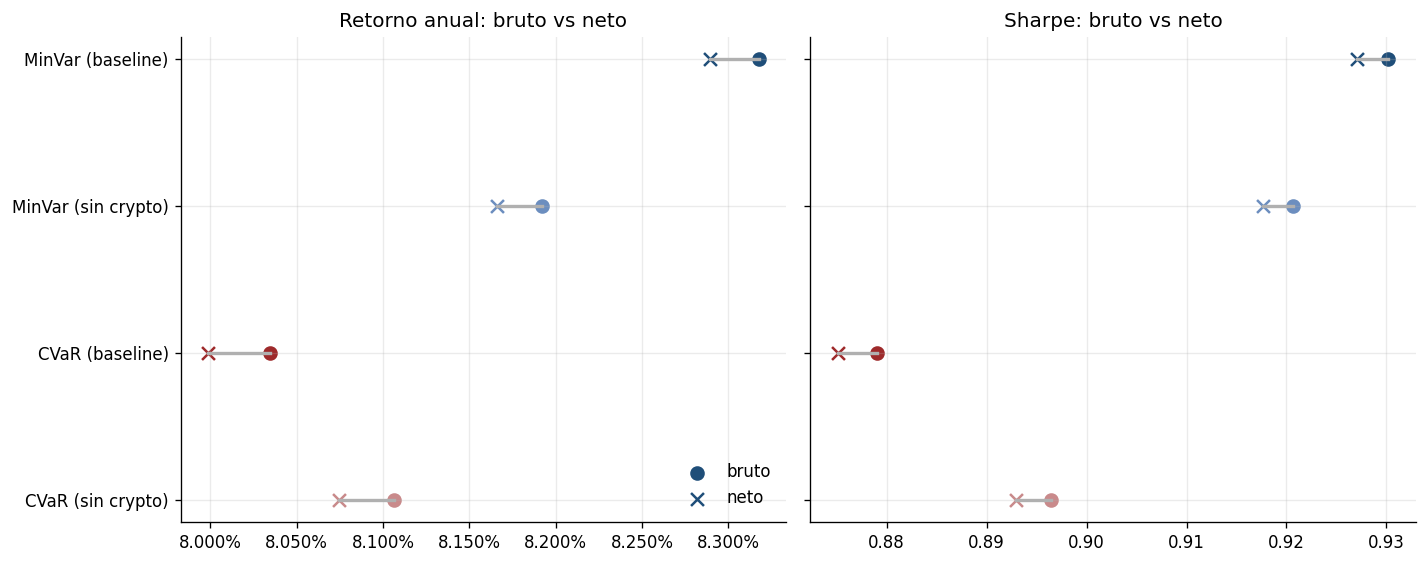

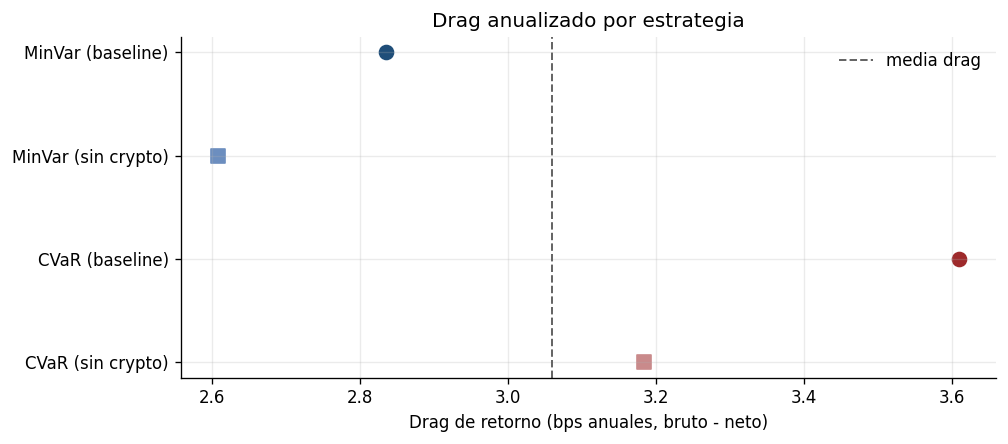

Ranking bruto vs neto (retorno y Sharpe):


,rank_ret_gross,rank_ret_net,rank_sharpe_gross,rank_sharpe_net
0,MinVar (baseline),MinVar (baseline),MinVar (baseline),MinVar (baseline)
1,MinVar (sin crypto),MinVar (sin crypto),MinVar (sin crypto),MinVar (sin crypto)
2,CVaR (sin crypto),CVaR (sin crypto),CVaR (sin crypto),CVaR (sin crypto)
3,CVaR (baseline),CVaR (baseline),CVaR (baseline),CVaR (baseline)


In [40]:
# 6.1 Tabla compacta bruto vs neto + drag en bps anuales.
gn = summary_net.copy()
gn = gn.set_index("strategy").loc[STRATEGY_ORDER].reset_index()
gn["display"] = gn["strategy"].map(label)
gn["drag_return_bps"] = (gn["ann_return_gross"] - gn["ann_return_net"]) * 10000.0

tab_gn = gn[[
    "display",
    "ann_return_gross", "ann_return_net",
    "sharpe_gross", "sharpe_net",
    "max_drawdown_gross", "max_drawdown_net",
    "expected_shortfall_gross", "expected_shortfall_net",
    "drag_return_bps",
]].copy()

tab_fmt = tab_gn.copy()
for c in [
    "ann_return_gross", "ann_return_net",
    "max_drawdown_gross", "max_drawdown_net",
    "expected_shortfall_gross", "expected_shortfall_net",
]:
    tab_fmt[c] = tab_fmt[c].map(lambda v: f"{v*100:.2f}%")
for c in ["sharpe_gross", "sharpe_net"]:
    tab_fmt[c] = tab_fmt[c].map(lambda v: f"{v:.3f}")
tab_fmt["drag_return_bps"] = tab_fmt["drag_return_bps"].map(lambda v: f"{v:.2f} bps")

tab_fmt = tab_fmt.rename(columns={
    "display": "Estrategia",
    "ann_return_gross": "Ret bruto",
    "ann_return_net": "Ret neto",
    "sharpe_gross": "Sharpe bruto",
    "sharpe_net": "Sharpe neto",
    "max_drawdown_gross": "MaxDD bruto",
    "max_drawdown_net": "MaxDD neto",
    "expected_shortfall_gross": "ES95 bruto",
    "expected_shortfall_net": "ES95 neto",
    "drag_return_bps": "Drag retorno",
})

# Drag = retorno bruto - retorno neto, expresado en bps anuales (no en bps por operación).
display(tab_fmt)

# 6.2 Dumbbell pareado: retorno y Sharpe (bruto vs neto) por estrategia.
plot_df = gn.copy()
y = np.arange(len(plot_df))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharey=True)
for i, sid in enumerate(plot_df["strategy"]):
    st = style_of(sid)

    xg = plot_df.loc[i, "ann_return_gross"]
    xn = plot_df.loc[i, "ann_return_net"]
    axes[0].plot([xn, xg], [y[i], y[i]], color="#b0b0b0", lw=2)
    axes[0].scatter(xg, y[i], color=st["color"], s=60, marker="o", label="bruto" if i == 0 else None)
    axes[0].scatter(xn, y[i], color=st["color"], s=60, marker="x", label="neto" if i == 0 else None)

    xg_s = plot_df.loc[i, "sharpe_gross"]
    xn_s = plot_df.loc[i, "sharpe_net"]
    axes[1].plot([xn_s, xg_s], [y[i], y[i]], color="#b0b0b0", lw=2)
    axes[1].scatter(xg_s, y[i], color=st["color"], s=60, marker="o")
    axes[1].scatter(xn_s, y[i], color=st["color"], s=60, marker="x")

axes[0].set_title("Retorno anual: bruto vs neto")
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].set_yticks(y)
axes[0].set_yticklabels(plot_df["display"])
axes[0].invert_yaxis()
axes[0].legend(frameon=False, loc="lower right")

axes[1].set_title("Sharpe: bruto vs neto")
axes[1].tick_params(axis="y", labelleft=False)

plt.tight_layout()
plt.show()

# 6.3 Drag anualizado de retorno por estrategia (bps).
fig, ax = plt.subplots(figsize=(8.5, 3.8))
for i, sid in enumerate(plot_df["strategy"]):
    st = style_of(sid)
    ax.scatter(plot_df.loc[i, "drag_return_bps"], i, s=70, color=st["color"], marker=st["marker"])

ax.axvline(plot_df["drag_return_bps"].mean(), color="#666", linestyle="--", lw=1.2, label="media drag")
ax.set_yticks(np.arange(len(plot_df)))
ax.set_yticklabels(plot_df["display"])
ax.invert_yaxis()
ax.set_xlabel("Drag de retorno (bps anuales, bruto - neto)")
ax.set_title("Drag anualizado por estrategia")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# 6.4 Chequeo de ranking bruto vs neto (retorno y Sharpe).
rankings = pd.DataFrame({
    "rank_ret_gross": gn.sort_values("ann_return_gross", ascending=False)["strategy"].tolist(),
    "rank_ret_net": gn.sort_values("ann_return_net", ascending=False)["strategy"].tolist(),
    "rank_sharpe_gross": gn.sort_values("sharpe_gross", ascending=False)["strategy"].tolist(),
    "rank_sharpe_net": gn.sort_values("sharpe_net", ascending=False)["strategy"].tolist(),
})
for c in rankings.columns:
    rankings[c] = rankings[c].map(DISPLAY_NAMES)

print("Ranking bruto vs neto (retorno y Sharpe):")
display(rankings)

Lectura económica bruto vs neto (§6):

- El paso a neto erosiona métricas de forma pequeña pero sistemática en las cuatro estrategias: no cambia la historia cualitativa, pero sí el nivel económico defendible.
- En esta muestra, el ranking bruto vs neto no se rompe; eso sugiere fricción contenida, no irrelevancia de costes.
- La estabilidad de ranking debe leerse junto al tamaño del drag: una compresión modesta y persistente sigue siendo relevante cuando se evalúan diferencias estrechas entre objetivos.
- Por diseño, el modelo usa costes lineales; por tanto, la sección mide fricción "base" de implementación, no el total de fricción que un desk afrontaría en vivo.

Mensaje de portfolio construction: net-of-cost confirma la señal agregada, pero con menor margen económico disponible para defender cambios de objetivo.

---
## 7 - Turnover e implementabilidad

Preguntas de trabajo:

- ¿CVaR exige más turnover?
- ¿Ese turnover adicional es operativo o económicamente relevante?
- ¿Los controles sin crypto parecen más fáciles de implementar?
- ¿Qué fricciones siguen fuera del modelo?

,Estrategia,Turnover medio,Turnover mediano,Turnover p90,Turnover máximo,Activos cambiados (media),% rebalanceos > 5%,% rebalanceos > 10%
0,MinVar (baseline),3.16%,2.17%,6.17%,30.88%,4.15,15.38%,3.30%
1,MinVar (sin crypto),2.91%,1.88%,6.17%,30.25%,3.46,14.29%,3.30%
2,CVaR (baseline),4.04%,2.10%,8.52%,35.25%,4.10,25.27%,7.69%
3,CVaR (sin crypto),3.56%,1.67%,8.49%,34.70%,3.47,20.88%,6.59%


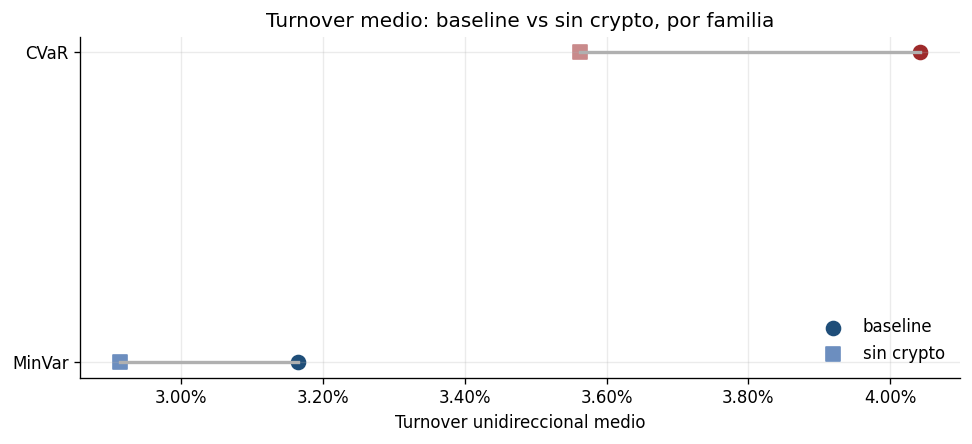

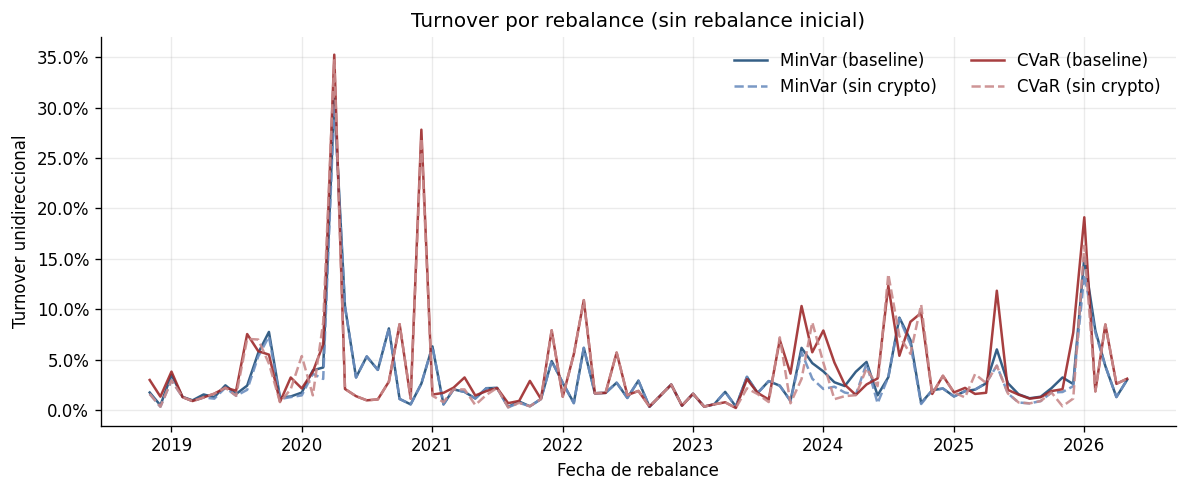

Diferencial de turnover medio (CVaR - MinVar):
  baseline: 0.88 pp
  sin_crypto: 0.65 pp


In [41]:
# 7.1 Tabla de implementabilidad (excluye rebalance inicial para no sesgar a la baja).
to = turnover_long.copy()
to = to[to["strategy"].isin(STRATEGY_ORDER)].copy()
to_work = to[~to["is_initial_rebalance"].fillna(False)].copy()

impl = (
    to_work.groupby("strategy")
    .agg(
        mean_turnover=("turnover_one_way", "mean"),
        median_turnover=("turnover_one_way", "median"),
        p90_turnover=("turnover_one_way", lambda x: x.quantile(0.90)),
        max_turnover=("turnover_one_way", "max"),
        mean_assets_changed=("n_assets_changed", "mean"),
        pct_reb_gt_5pct=("turnover_one_way", lambda x: (x > 0.05).mean()),
        pct_reb_gt_10pct=("turnover_one_way", lambda x: (x > 0.10).mean()),
    )
    .loc[STRATEGY_ORDER]
    .reset_index()
)
impl["display"] = impl["strategy"].map(label)

impl_fmt = impl[[
    "display", "mean_turnover", "median_turnover", "p90_turnover", "max_turnover",
    "mean_assets_changed", "pct_reb_gt_5pct", "pct_reb_gt_10pct"
]].copy()
for c in ["mean_turnover", "median_turnover", "p90_turnover", "max_turnover", "pct_reb_gt_5pct", "pct_reb_gt_10pct"]:
    impl_fmt[c] = impl_fmt[c].map(lambda v: f"{v*100:.2f}%")
impl_fmt["mean_assets_changed"] = impl_fmt["mean_assets_changed"].map(lambda v: f"{v:.2f}")

impl_fmt = impl_fmt.rename(columns={
    "display": "Estrategia",
    "mean_turnover": "Turnover medio",
    "median_turnover": "Turnover mediano",
    "p90_turnover": "Turnover p90",
    "max_turnover": "Turnover máximo",
    "mean_assets_changed": "Activos cambiados (media)",
    "pct_reb_gt_5pct": "% rebalanceos > 5%",
    "pct_reb_gt_10pct": "% rebalanceos > 10%",
})

display(impl_fmt)

# 7.2 Comparación pareada baseline vs sin crypto (turnover medio) por familia.
pair_df = impl[["strategy", "mean_turnover", "display"]].copy()
pair_map = [
    ("minvar_baseline_ch1", "minvar_no_crypto_control", "MinVar"),
    ("cvar_baseline", "cvar_no_crypto_control", "CVaR"),
]

fig, ax = plt.subplots(figsize=(8.2, 3.8))
for j, (s_base, s_ctrl, fam) in enumerate(pair_map):
    y = j
    x1 = float(pair_df.loc[pair_df["strategy"] == s_base, "mean_turnover"].iloc[0])
    x2 = float(pair_df.loc[pair_df["strategy"] == s_ctrl, "mean_turnover"].iloc[0])
    ax.plot([x1, x2], [y, y], color="#b0b0b0", lw=2)
    ax.scatter(x1, y, s=70, color=style_of(s_base)["color"], marker="o", label="baseline" if j == 0 else None)
    ax.scatter(x2, y, s=70, color=style_of(s_ctrl)["color"], marker="s", label="sin crypto" if j == 0 else None)

ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_yticks([0, 1])
ax.set_yticklabels(["MinVar", "CVaR"])
ax.set_title("Turnover medio: baseline vs sin crypto, por familia")
ax.set_xlabel("Turnover unidireccional medio")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

# 7.3 Serie temporal de turnover por rebalance (excluye inicial).
fig, ax = plt.subplots(figsize=(10, 4.2))
for sid in STRATEGY_ORDER:
    d = to_work[to_work["strategy"] == sid].sort_values("rebalance_date")
    st = style_of(sid)
    ax.plot(d["rebalance_date"], d["turnover_one_way"], color=st["color"], linestyle=st["linestyle"], lw=1.5, alpha=0.9, label=label(sid))

ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Turnover por rebalance (sin rebalance inicial)")
ax.set_ylabel("Turnover unidireccional")
ax.set_xlabel("Fecha de rebalance")
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

# 7.4 Diferencial de turnover medio CVaR vs MinVar dentro de cada variante.
mean_turn = impl.set_index("strategy")["mean_turnover"]
delta_family = {
    "baseline": mean_turn["cvar_baseline"] - mean_turn["minvar_baseline_ch1"],
    "sin_crypto": mean_turn["cvar_no_crypto_control"] - mean_turn["minvar_no_crypto_control"],
}
print("Diferencial de turnover medio (CVaR - MinVar):")
for k, v in delta_family.items():
    print(f"  {k}: {v*100:.2f} pp")

Lectura económica de implementabilidad (§7):

- CVaR muestra mayor rotación media que MinVar en baseline y en control sin crypto, señal de un coste operativo adicional asociado al objetivo de cola.
- Ese diferencial de turnover debe leerse como **trade-off operativo**: incluso si hubiera mejora puntual de cola, no es gratuita en términos de ejecución.
- Turnover bajo ayuda, pero no equivale a implementabilidad total: faltan capacidad, profundidad, latencia, slippage e impacto, especialmente en episodios de mercado tensos.
- Excluir el rebalance inicial es metodológicamente correcto para no contaminar la lectura con un pico mecánico no recurrente.

Conclusión de sección: la decisión MinVar vs CVaR no es solo estadística; también es una decisión de presupuesto de fricción operativa.

---
## 8 - Ventanas históricas de estrés

Esta sección conecta la comparación MinVar vs CVaR con tres episodios adversos predefinidos en `stress_summary.csv`:

- COVID crash
- stress de tipos / stock-bond en 2022
- stress cripto en 2022

El objetivo es diagnóstico: evaluar si la lectura agregada del capítulo se sostiene dentro de ventanas de estrés concretas y si cambia al pasar de bruto a neto.

No se introduce inferencia causal ni generalización universal a otros regímenes.


Tabla 8.1: estrés por ventana/vista/estrategia (métricas clave).
Lectura: resumen descriptivo; en ventanas cortas el retorno anualizado puede sobredimensionar magnitudes.


,Ventana de estrés,Vista,Estrategia,Ret anual,ES95,MaxDD
0,2022 crypto stress,Bruto,CVaR (baseline),-12.86%,1.63%,-20.45%
1,2022 crypto stress,Bruto,CVaR (sin crypto),-12.86%,1.63%,-20.45%
2,2022 crypto stress,Bruto,MinVar (baseline),-12.98%,1.63%,-20.57%
3,2022 crypto stress,Bruto,MinVar (sin crypto),-12.98%,1.63%,-20.57%
4,2022 crypto stress,Neto,CVaR (baseline),-12.88%,1.63%,-20.46%
5,2022 crypto stress,Neto,CVaR (sin crypto),-12.88%,1.63%,-20.46%
6,2022 crypto stress,Neto,MinVar (baseline),-12.99%,1.63%,-20.58%
7,2022 crypto stress,Neto,MinVar (sin crypto),-12.99%,1.63%,-20.58%
8,2022 rates / stock-bond stress,Bruto,CVaR (baseline),-18.79%,1.61%,-23.05%
9,2022 rates / stock-bond stress,Bruto,CVaR (sin crypto),-18.79%,1.61%,-23.05%


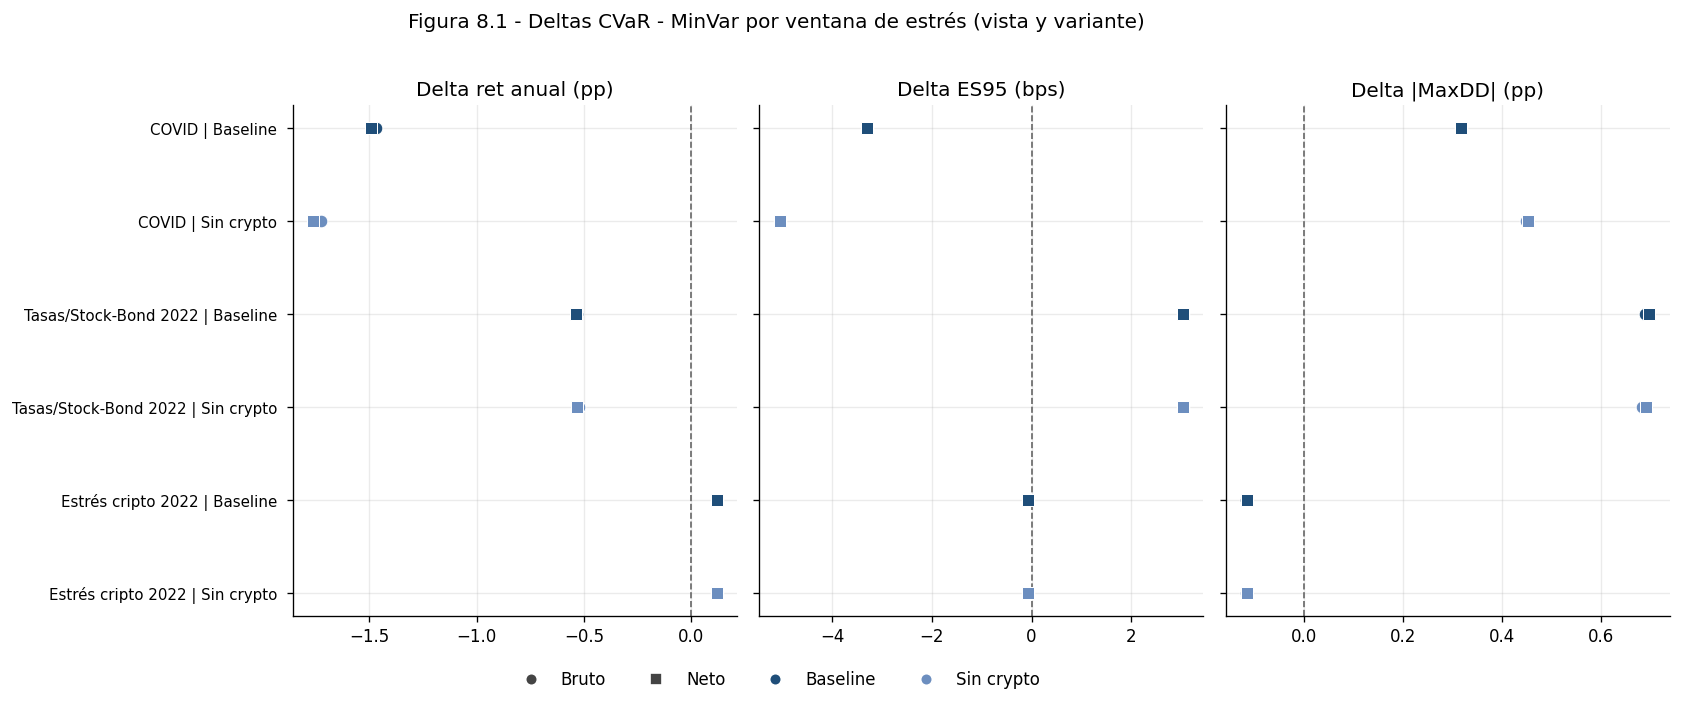

Consistencia descriptiva CVaR vs MinVar - Retorno: 4/12 | ES95: 8/12 | |MaxDD|: 4/12


In [42]:
# 8.1 Tabla compacta de estrés por ventana, vista y estrategia.
stress = stress_long.copy()
stress = stress[
    stress["strategy"].isin(STRATEGY_ORDER)
    & stress["scope"].isin(["gross", "net"])
].copy()

WINDOW_LABEL_ORDER = [
    "COVID crash",
    "2022 rates / stock-bond stress",
    "2022 crypto stress",
]

WINDOW_SHORT = {
    "COVID crash": "COVID",
    "2022 rates / stock-bond stress": "Tasas/Stock-Bond 2022",
    "2022 crypto stress": "Estrés cripto 2022",
}

VARIANT_LABEL = {
    "baseline": "Baseline",
    "sin crypto": "Sin crypto",
}

stress["window_display"] = stress["window_label"]
stress["strategy_display"] = stress["strategy"].map(DISPLAY_NAMES)
stress["scope_display"] = stress["scope"].map({"gross": "Bruto", "net": "Neto"})
stress["family"] = stress["strategy"].map(FAMILY_OF)
stress["variant"] = stress["strategy"].map(VARIANT_OF)

# Tabla compacta: solo métricas clave de estrés (retorno, ES95, MaxDD).
stress_table = (
    stress[["window_display", "scope_display", "strategy_display", "ann_return", "expected_shortfall", "max_drawdown"]]
    .rename(columns={
        "window_display": "Ventana de estrés",
        "scope_display": "Vista",
        "strategy_display": "Estrategia",
        "ann_return": "Ret anual",
        "expected_shortfall": "ES95",
        "max_drawdown": "MaxDD",
    })
    .sort_values(["Ventana de estrés", "Vista", "Estrategia"])
    .reset_index(drop=True)
)

stress_table_fmt = stress_table.copy()
for c in ["Ret anual", "ES95", "MaxDD"]:
    stress_table_fmt[c] = stress_table_fmt[c].map(lambda v: f"{v*100:.2f}%")

print("Tabla 8.1: estrés por ventana/vista/estrategia (métricas clave).")
print("Lectura: resumen descriptivo; en ventanas cortas el retorno anualizado puede sobredimensionar magnitudes.")
display(stress_table_fmt)

# 8.2 Figura principal: deltas CVaR - MinVar por ventana, variante y vista.
# Convención: en ES95 y |MaxDD|, delta negativo favorece a CVaR.
pair_rows = []
for window in WINDOW_LABEL_ORDER:
    for scope in ["gross", "net"]:
        for min_id, cvar_id, variant in [
            ("minvar_baseline_ch1", "cvar_baseline", "baseline"),
            ("minvar_no_crypto_control", "cvar_no_crypto_control", "sin crypto"),
        ]:
            d_min = stress[(stress["window_display"] == window) & (stress["scope"] == scope) & (stress["strategy"] == min_id)]
            d_cvar = stress[(stress["window_display"] == window) & (stress["scope"] == scope) & (stress["strategy"] == cvar_id)]
            if d_min.empty or d_cvar.empty:
                continue

            m = d_min.iloc[0]
            c = d_cvar.iloc[0]
            pair_rows.append(
                {
                    "window": window,
                    "window_short": WINDOW_SHORT.get(window, window),
                    "scope": scope,
                    "scope_label": {"gross": "Bruto", "net": "Neto"}.get(scope, scope),
                    "variant": variant,
                    "variant_label": VARIANT_LABEL.get(variant, variant),
                    "Delta Ret anual (pp)": (c["ann_return"] - m["ann_return"]) * 100.0,
                    "Delta ES95 (bps)": (c["expected_shortfall"] - m["expected_shortfall"]) * 10000.0,
                    "Delta |MaxDD| (pp)": (abs(c["max_drawdown"]) - abs(m["max_drawdown"])) * 100.0,
                }
            )

pair_cmp = pd.DataFrame(pair_rows)

if pair_cmp.empty:
    raise ValueError("No se pudo construir la comparación de deltas de estrés.")

# Orden y etiqueta compacta para eje Y (sin labels largos rotados).
row_order = []
for w in WINDOW_LABEL_ORDER:
    for v in ["baseline", "sin crypto"]:
        row_order.append((w, v))

pair_cmp["row_key"] = list(zip(pair_cmp["window"], pair_cmp["variant"]))
pair_cmp["row_order"] = pair_cmp["row_key"].apply(lambda x: row_order.index(x) if x in row_order else 999)
pair_cmp = pair_cmp.sort_values(["row_order", "scope"]).reset_index(drop=True)

row_labels = []
for w, v in row_order:
    row_labels.append(f"{WINDOW_SHORT[w]} | {VARIANT_LABEL[v]}")

y_map = {(w, v): i for i, (w, v) in enumerate(row_order)}
pair_cmp["y"] = pair_cmp["row_key"].map(y_map)

scope_marker = {"gross": "o", "net": "s"}
variant_color = {"baseline": "#1f4e79", "sin crypto": "#6c8ebf"}

metrics = ["Delta ret anual (pp)", "Delta ES95 (bps)", "Delta |MaxDD| (pp)"]
fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.6), sharey=True)
metric_map = {
    "Delta ret anual (pp)": "Delta Ret anual (pp)",
    "Delta ES95 (bps)": "Delta ES95 (bps)",
    "Delta |MaxDD| (pp)": "Delta |MaxDD| (pp)",
}

for ax, metric_title in zip(axes, metrics):
    metric = metric_map[metric_title]

    # Línea de referencia en cero: sin diferencia entre objetivos.
    ax.axvline(0.0, color="#666666", linestyle="--", lw=1.0)

    # Conectar bruto-neto dentro de cada (ventana, variante).
    for (_, _), grp in pair_cmp.groupby("row_key"):
        grp = grp.sort_values("scope")
        if grp.shape[0] == 2:
            ax.plot(grp[metric].values, grp["y"].values, color="#c0c0c0", lw=1.5, zorder=1)

    # Puntos: color por variante, marcador por vista.
    for _, r in pair_cmp.iterrows():
        ax.scatter(
            r[metric],
            r["y"],
            s=58,
            color=variant_color[r["variant"]],
            marker=scope_marker[r["scope"]],
            edgecolor="white",
            linewidth=0.6,
            zorder=3,
        )

    ax.set_title(metric_title)
    ax.grid(axis="x", alpha=0.25)

axes[0].set_yticks(np.arange(len(row_labels)))
axes[0].set_yticklabels(row_labels, fontsize=9)
axes[0].invert_yaxis()
axes[0].tick_params(axis="y", pad=6, labelleft=True)

for ax in axes[1:]:
    ax.tick_params(axis="y", labelleft=False)

from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#444444", markeredgecolor="white", markersize=7, label="Bruto"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor="#444444", markeredgecolor="white", markersize=7, label="Neto"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=variant_color["baseline"], markeredgecolor="white", markersize=7, label="Baseline"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=variant_color["sin crypto"], markeredgecolor="white", markersize=7, label="Sin crypto"),
]
fig.legend(handles=legend_items, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.01))

fig.suptitle("Figura 8.1 - Deltas CVaR - MinVar por ventana de estrés (vista y variante)", y=1.02)
fig.subplots_adjust(left=0.24, right=0.98, bottom=0.12, top=0.88, wspace=0.05)
plt.show()

# Lectura de consistencia (texto breve): cuántas comparaciones favorecen a CVaR por métrica.
ret_wins = int((pair_cmp["Delta Ret anual (pp)"] > 0).sum())
es_wins = int((pair_cmp["Delta ES95 (bps)"] < 0).sum())
mdd_wins = int((pair_cmp["Delta |MaxDD| (pp)"] < 0).sum())
total_cmp = int(pair_cmp.shape[0])

print(
    f"Consistencia descriptiva CVaR vs MinVar - Retorno: {ret_wins}/{total_cmp} | "
    f"ES95: {es_wins}/{total_cmp} | |MaxDD|: {mdd_wins}/{total_cmp}"
)

Lectura económica de ventanas de estrés (§8, diagnóstico condicional):

1. ¿Qué añade esta sección respecto al agregado?
Añade granularidad por episodio: muestra cuándo la lectura promedio se confirma y cuándo se debilita, separando explícitamente retorno, cola (ES95) y drawdown.

2. ¿CVaR mejora frente a MinVar en cada ventana?
La lectura correcta está en los **deltas CVaR - MinVar** por métrica. En la figura, valores a la izquierda de cero favorecen a CVaR en ES95 y |MaxDD|, mientras que valores a la derecha favorecen a CVaR en retorno.

3. ¿La señal es consistente?
No. La evidencia es heterogénea por ventana y por dimensión: hay episodios donde CVaR mejora cola sin mejorar retorno, y otros donde ocurre lo contrario. Eso es exactamente lo esperable en análisis condicional.

4. ¿Cambia la lectura al pasar de bruto a neto?
La distancia entre marcador Bruto y Neto dentro de cada fila muestra cuánto altera costes la comparación relativa. Si el desplazamiento es pequeño, la lectura sobrevive neta de costes; si cruza el cero, la conclusión económica debe matizarse.

5. Sobre retorno anualizado en ventanas cortas
El retorno anual en ventanas de estrés sirve para comparación relativa entre estrategias, no para inferencia fuerte en magnitud absoluta. No debe dramatizarse.

6. Qué no puede generalizarse
Tres episodios históricos no demuestran robustez universal ni causalidad. Son evidencia útil para risk review, pero insuficiente para cerrar la discusión sin análisis por regímenes.

---
## 9 - Pesos y uso efectivo del sleeve cripto

Esta sección evalúa si la exposición cripto actúa como bloque estructural o como sleeve contingente.  
El análisis usa exclusivamente `tail_risk_weights_panel.csv` (ya cargado como `weights_long`) y se centra en cuatro comparadores:

- MinVar (baseline)
- MinVar (sin crypto)
- CVaR (baseline)
- CVaR (sin crypto)

Umbrales de materialidad usados:

- Exposición material: crypto > 2%
- Casi cero: crypto <= 1%

Los residuos numéricos muy pequeños se tratan como ruido computacional.


,Estrategia,Peso cripto medio,Peso cripto mediano,Peso cripto p90,Peso cripto máximo,% de rebalanceos > 2%,% de rebalanceos <= 1%,N.º de rebalanceos
0,MinVar (baseline),0.76%,0.00%,2.68%,4.76%,15.22%,76.09%,92
1,MinVar (sin crypto),0.00%,0.00%,0.00%,0.00%,0.00%,100.00%,92
2,CVaR (baseline),1.81%,0.01%,5.70%,12.55%,22.83%,67.39%,92
3,CVaR (sin crypto),0.00%,0.00%,0.00%,0.00%,0.00%,100.00%,92


Chequeo controles sin crypto - max_crypto_weight observado: 0.000000e+00


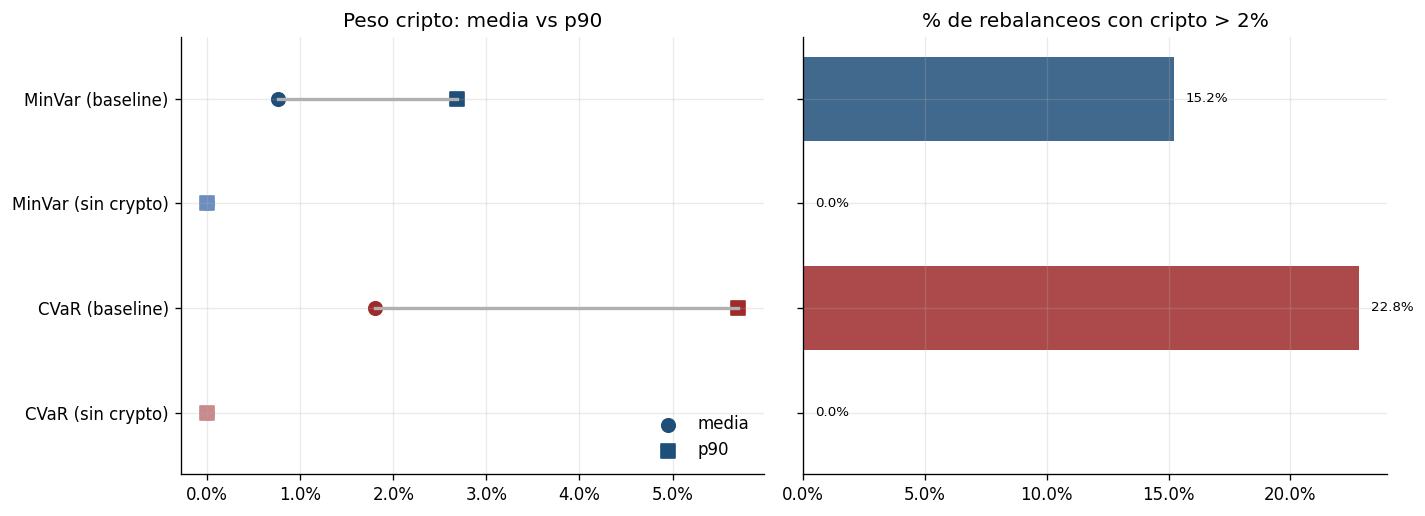

In [43]:
# 9.1 Métricas de uso del sleeve cripto por estrategia + visual compacto.
crypto_assets = ["BTC-USD", "ETH-USD"]

w = weights_long.copy()
w = w[w["strategy"].isin(STRATEGY_ORDER)].copy()

# Si cambian tickers en el futuro, fallback por patrón BTC/ETH.
available_tickers = set(w["ticker"].unique())
crypto_in_data = [t for t in crypto_assets if t in available_tickers]
if len(crypto_in_data) == 0:
    crypto_in_data = [t for t in available_tickers if ("BTC" in t.upper() or "ETH" in t.upper())]

w_crypto = (
    w[w["ticker"].isin(crypto_in_data)]
    .groupby(["strategy", "rebalance_date"], as_index=False)["weight"]
    .sum()
    .rename(columns={"weight": "crypto_weight"})
)

# Limpieza numérica: residuos ínfimos se consideran 0 (ruido computacional, no exposición económica).
w_crypto["crypto_weight"] = w_crypto["crypto_weight"].where(w_crypto["crypto_weight"].abs() > 1e-12, 0.0)

usage = (
    w_crypto.groupby("strategy")
    .agg(
        mean_crypto_weight=("crypto_weight", "mean"),
        median_crypto_weight=("crypto_weight", "median"),
        p90_crypto_weight=("crypto_weight", lambda x: x.quantile(0.90)),
        max_crypto_weight=("crypto_weight", "max"),
        share_crypto_gt_2pct=("crypto_weight", lambda x: (x > 0.02).mean()),
        share_crypto_le_1pct=("crypto_weight", lambda x: (x <= 0.01).mean()),
        n_rebalances=("crypto_weight", "size"),
    )
    .reindex(STRATEGY_ORDER)
    .reset_index()
)
usage["display"] = usage["strategy"].map(DISPLAY_NAMES)

usage_table = usage[[
    "display",
    "mean_crypto_weight",
    "median_crypto_weight",
    "p90_crypto_weight",
    "max_crypto_weight",
    "share_crypto_gt_2pct",
    "share_crypto_le_1pct",
    "n_rebalances",
]].copy()

usage_fmt = usage_table.copy()
for c in [
    "mean_crypto_weight",
    "median_crypto_weight",
    "p90_crypto_weight",
    "max_crypto_weight",
    "share_crypto_gt_2pct",
    "share_crypto_le_1pct",
]:
    usage_fmt[c] = usage_fmt[c].map(lambda v: f"{v*100:.2f}%")
usage_fmt = usage_fmt.rename(columns={
    "display": "Estrategia",
    "mean_crypto_weight": "Peso cripto medio",
    "median_crypto_weight": "Peso cripto mediano",
    "p90_crypto_weight": "Peso cripto p90",
    "max_crypto_weight": "Peso cripto máximo",
    "share_crypto_gt_2pct": "% de rebalanceos > 2%",
    "share_crypto_le_1pct": "% de rebalanceos <= 1%",
    "n_rebalances": "N.º de rebalanceos",
})

display(usage_fmt)

# Chequeo de limpieza en controles sin crypto: se espera ruido numérico, no exposición.
controls = usage[usage["strategy"].isin(["minvar_no_crypto_control", "cvar_no_crypto_control"])].copy()
max_control_crypto = controls["max_crypto_weight"].max()
print(f"Chequeo controles sin crypto - max_crypto_weight observado: {max_control_crypto:.6e}")

# 9.2 Figura única con dos paneles: intensidad (media/p90) y frecuencia material (>2%).
plot_df = usage.set_index("strategy").loc[STRATEGY_ORDER].reset_index()
y = np.arange(len(plot_df))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)

# Panel A: intensidad - media vs p90 del peso cripto.
for i, sid in enumerate(plot_df["strategy"]):
    st = style_of(sid)
    x_mean = plot_df.loc[i, "mean_crypto_weight"]
    x_p90 = plot_df.loc[i, "p90_crypto_weight"]
    axes[0].plot([x_mean, x_p90], [y[i], y[i]], color="#b0b0b0", lw=2)
    axes[0].scatter(x_mean, y[i], color=st["color"], s=65, marker="o", label="media" if i == 0 else None)
    axes[0].scatter(x_p90, y[i], color=st["color"], s=65, marker="s", label="p90" if i == 0 else None)

axes[0].set_title("Peso cripto: media vs p90")
axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].set_yticks(y)
axes[0].set_yticklabels(plot_df["display"])
axes[0].invert_yaxis()
axes[0].legend(frameon=False, loc="lower right")

# Panel B: frecuencia - % de rebalanceos con activación material (>2%).
bars = axes[1].barh(y, plot_df["share_crypto_gt_2pct"], color=[style_of(s)["color"] for s in plot_df["strategy"]], alpha=0.85)
axes[1].set_title("% de rebalanceos con cripto > 2%")
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].tick_params(axis="y", labelleft=False)
for rect, val in zip(bars, plot_df["share_crypto_gt_2pct"]):
    axes[1].text(val + 0.005, rect.get_y() + rect.get_height() / 2, f"{val*100:.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

Lectura económica del sleeve cripto (§9):

1. Uso efectivo vs uso estructural
MinVar muestra uso bajo e intermitente del sleeve cripto; CVaR lo activa más en intensidad/frecuencia, pero sin patrón de asignación permanente.

2. Lo que sí puede decirse
La evidencia describe diferencias de comportamiento de pesos entre objetivos bajo el mismo protocolo: CVaR tiende a tolerar/activar más exposición cripto en algunos rebalances.

3. Lo que no puede decirse
Eso no prueba causalidad, no demuestra que cripto sea el motor principal del desempeño relativo y no valida una tesis de diversificación estable en estrés.

4. Controles sin crypto
Los controles permanecen limpios (residuos numéricos próximos a cero), por lo que el contraste baseline vs sin crypto sigue siendo metodológicamente útil.

5. Conclusión prudente
La lectura sostenible es "sleeve contingente" y no "bloque estructural": uso efectivo no equivale a contribución causal.

---
## 10 - Qué cambia al pasar de varianza a cola

Esta sección sintetiza, sin añadir experimentos, la evidencia acumulada en §4-§9 para responder una pregunta central:

**¿Qué cambia realmente al sustituir MinVar por un objetivo histórico CVaR?**

La lectura separa diferencia descriptiva, relevancia económica y límite inferencial.


In [38]:
# 10.1 Tabla de síntesis integrada (sin experimento nuevo: agrega evidencia de §4 a §9).
minvar_ids = ["minvar_baseline_ch1", "minvar_no_crypto_control"]
cvar_ids = ["cvar_baseline", "cvar_no_crypto_control"]

sg = summary_gross.copy().set_index("strategy")
sn = summary_net.copy().set_index("strategy")

# Retorno / Sharpe y cola en agregado de familia.
ret_minvar = float(sg.loc[minvar_ids, "ann_return"].mean())
ret_cvar = float(sg.loc[cvar_ids, "ann_return"].mean())
sh_minvar = float(sg.loc[minvar_ids, "sharpe"].mean())
sh_cvar = float(sg.loc[cvar_ids, "sharpe"].mean())
es_minvar = float(sg.loc[minvar_ids, "expected_shortfall"].mean())
es_cvar = float(sg.loc[cvar_ids, "expected_shortfall"].mean())
mdd_minvar = float(sg.loc[minvar_ids, "max_drawdown"].abs().mean())
mdd_cvar = float(sg.loc[cvar_ids, "max_drawdown"].abs().mean())

# Bruto vs neto: cambios de ranking (ordenamiento absoluto del listado).
ret_rank_gross = sn.sort_values("ann_return_gross", ascending=False).index.tolist()
ret_rank_net = sn.sort_values("ann_return_net", ascending=False).index.tolist()
sh_rank_gross = sn.sort_values("sharpe_gross", ascending=False).index.tolist()
sh_rank_net = sn.sort_values("sharpe_net", ascending=False).index.tolist()
ret_rank_changed = ret_rank_gross != ret_rank_net
sh_rank_changed = sh_rank_gross != sh_rank_net

# Ventanas de estrés: conteo de "wins" CVaR vs MinVar por ventana-vista-variante.
st = stress_long.copy()
st = st[st["strategy"].isin(STRATEGY_ORDER) & st["scope"].isin(["gross", "net"])].copy()

stress_comp = []
for window in sorted(st["window_label"].unique()):
    for scope in ["gross", "net"]:
        for min_id, cvar_id, variant in [
            ("minvar_baseline_ch1", "cvar_baseline", "baseline"),
            ("minvar_no_crypto_control", "cvar_no_crypto_control", "sin crypto"),
        ]:
            dmin = st[(st["window_label"] == window) & (st["scope"] == scope) & (st["strategy"] == min_id)]
            dcva = st[(st["window_label"] == window) & (st["scope"] == scope) & (st["strategy"] == cvar_id)]
            if dmin.empty or dcva.empty:
                continue
            m = dmin.iloc[0]
            c = dcva.iloc[0]
            stress_comp.append({
                "window": window,
                "scope": scope,
                "variant": variant,
                "ret_win": c["ann_return"] > m["ann_return"],
                "es_win": c["expected_shortfall"] < m["expected_shortfall"],
                "mdd_win": abs(c["max_drawdown"]) < abs(m["max_drawdown"]),
            })

stress_cmp = pd.DataFrame(stress_comp)
ret_wins = int(stress_cmp["ret_win"].sum()) if not stress_cmp.empty else 0
es_wins = int(stress_cmp["es_win"].sum()) if not stress_cmp.empty else 0
mdd_wins = int(stress_cmp["mdd_win"].sum()) if not stress_cmp.empty else 0
total_stress_cmp = int(len(stress_cmp))

# Turnover.
turn_minvar = float(sg.loc[minvar_ids, "mean_turnover"].mean())
turn_cvar = float(sg.loc[cvar_ids, "mean_turnover"].mean())

# Sleeve cripto (recomputado para independencia de ejecución previa).
crypto_assets = ["BTC-USD", "ETH-USD"]
wc = weights_long[weights_long["ticker"].isin(crypto_assets) & weights_long["strategy"].isin(STRATEGY_ORDER)].copy()
wc = (
    wc.groupby(["strategy", "rebalance_date"], as_index=False)["weight"]
    .sum()
    .rename(columns={"weight": "crypto_weight"})
)
wc["crypto_weight"] = wc["crypto_weight"].where(wc["crypto_weight"].abs() > 1e-12, 0.0)

crypto_usage = wc.groupby("strategy").agg(
    mean_crypto_weight=("crypto_weight", "mean"),
    median_crypto_weight=("crypto_weight", "median"),
    share_crypto_gt_2pct=("crypto_weight", lambda x: (x > 0.02).mean()),
).reindex(STRATEGY_ORDER)

controls_clean = bool(
    wc[wc["strategy"].isin(["minvar_no_crypto_control", "cvar_no_crypto_control"])]["crypto_weight"].max() <= 1e-12
)

synth_rows = [
    {
        "Dimensión": "Retorno / Sharpe (OOS bruto)",
        "Evidencia": f"Ret anual medio MinVar {ret_minvar*100:.2f}% vs CVaR {ret_cvar*100:.2f}%; Sharpe medio MinVar {sh_minvar:.3f} vs CVaR {sh_cvar:.3f}.",
        "Lectura": "El cambio de objetivo altera el perfil de riesgo-retorno de forma observable, con menor rendimiento relativo de CVaR en esta muestra agregada.",
        "Límite de inferencia": "Resultado descriptivo OOS único; no implica superioridad estructural fuera de muestra.",
    },
    {
        "Dimensión": "Expected Shortfall",
        "Evidencia": f"ES95 medio MinVar {es_minvar*100:.3f}% vs CVaR {es_cvar*100:.3f}% (delta CVaR-MinVar {(es_cvar-es_minvar)*10000:.2f} bps).",
        "Lectura": "El objetivo CVaR no garantiza mejora uniforme de cola ex post; el efecto depende de muestra y episodio.",
        "Límite de inferencia": "No puede afirmarse que CVaR controle sistemáticamente la cola en todo régimen.",
    },
    {
        "Dimensión": "Max Drawdown",
        "Evidencia": f"|MaxDD| medio MinVar {mdd_minvar*100:.2f}% vs CVaR {mdd_cvar*100:.2f}% (delta {(mdd_cvar-mdd_minvar)*100:.2f} pp).",
        "Lectura": "El cambio de objetivo no resuelve por sí mismo el problema de drawdown en esta muestra.",
        "Límite de inferencia": "MaxDD es sensible al camino temporal; requiere cautela al extrapolar.",
    },
    {
        "Dimensión": "Bruto vs neto de costes",
        "Evidencia": f"Cambio de ranking por retorno: {ret_rank_changed}; por Sharpe: {sh_rank_changed}.",
        "Lectura": "La lectura neta de costes conserva la jerarquía observada en bruto, con compresión de métricas.",
        "Límite de inferencia": "No implica irrelevancia de costes; solo indica que aquí no cambian el orden relativo.",
    },
    {
        "Dimensión": "Ventanas de estrés",
        "Evidencia": f"Comparaciones CVaR vs MinVar (ventana-vista-variante={total_stress_cmp}): wins de CVaR en retorno {ret_wins}, en ES {es_wins}, en MaxDD {mdd_wins}.",
        "Lectura": "La evidencia de estrés es mixta y condicional al episodio; no hay dominancia robusta en todas las métricas.",
        "Límite de inferencia": "Tres ventanas históricas no prueban causalidad ni robustez universal.",
    },
    {
        "Dimensión": "Turnover",
        "Evidencia": f"Turnover medio MinVar {turn_minvar*100:.2f}% vs CVaR {turn_cvar*100:.2f}% (delta {(turn_cvar-turn_minvar)*100:.2f} pp).",
        "Lectura": "El mayor turnover de CVaR se lee como trade-off operativo frente a posibles mejoras puntuales de cola.",
        "Límite de inferencia": "Turnover no agota implementabilidad; faltan fricciones de mercado y capacidad.",
    },
    {
        "Dimensión": "Sleeve cripto",
        "Evidencia": (
            f"MinVar baseline: media {crypto_usage.loc['minvar_baseline_ch1','mean_crypto_weight']*100:.2f}% / mediana {crypto_usage.loc['minvar_baseline_ch1','median_crypto_weight']*100:.2f}% / share>2% {crypto_usage.loc['minvar_baseline_ch1','share_crypto_gt_2pct']*100:.1f}%. "
            f"CVaR baseline: media {crypto_usage.loc['cvar_baseline','mean_crypto_weight']*100:.2f}% / mediana {crypto_usage.loc['cvar_baseline','median_crypto_weight']*100:.2f}% / share>2% {crypto_usage.loc['cvar_baseline','share_crypto_gt_2pct']*100:.1f}%."
        ),
        "Lectura": "CVaR activa más el sleeve cripto que MinVar, pero el uso sigue siendo contingente/episódico y no permanente.",
        "Límite de inferencia": "No puede atribuirse de forma causal la diferencia MinVar-CVaR únicamente al sleeve cripto.",
    },
    {
        "Dimensión": "Qué no cambia / qué no puede afirmarse",
        "Evidencia": f"Controles sin crypto limpios: {controls_clean}. Persisten límites de muestra única y análisis descriptivo.",
        "Lectura": "No hay base para afirmar superioridad universal de CVaR; sí hay evidencia de cambio de perfil con trade-offs explícitos.",
        "Límite de inferencia": "La conclusión sostenible es condicional a protocolo, universo, costes y periodo OOS observados.",
    },
]

synth_table = pd.DataFrame(synth_rows)
display(synth_table)

,Dimensión,Evidencia,Lectura,Límite de inferencia
0,Retorno / Sharpe (OOS bruto),Ret anual medio MinVar 8.25% vs CVaR 8.07%; Sh...,El cambio de objetivo altera el perfil de ries...,Resultado descriptivo OOS único; no implica su...
1,Expected Shortfall,ES95 medio MinVar 1.336% vs CVaR 1.374% (delta...,El objetivo CVaR no garantiza mejora uniforme ...,No puede afirmarse que CVaR controle sistemáti...
2,Max Drawdown,|MaxDD| medio MinVar 23.34% vs CVaR 23.98% (de...,El cambio de objetivo no resuelve por sí mismo...,MaxDD es sensible al camino temporal; requiere...
3,Bruto vs neto de costes,Cambio de ranking por retorno: False; por Shar...,La lectura neta de costes conserva la jerarquí...,No implica irrelevancia de costes; solo indica...
4,Ventanas de estrés,Comparaciones CVaR vs MinVar (ventana-vista-va...,La evidencia de estrés es mixta y condicional ...,Tres ventanas históricas no prueban causalidad...
5,Turnover,Turnover medio MinVar 3.04% vs CVaR 3.80% (del...,El mayor turnover de CVaR se lee como trade-of...,Turnover no agota implementabilidad; faltan fr...
6,Sleeve cripto,MinVar baseline: media 0.76% / mediana 0.00% /...,"CVaR activa más el sleeve cripto que MinVar, p...",No puede atribuirse de forma causal la diferen...
7,Qué no cambia / qué no puede afirmarse,Controles sin crypto limpios: True. Persisten ...,No hay base para afirmar superioridad universa...,La conclusión sostenible es condicional a prot...


Lectura integrada (§10, respuesta corta):

- **Qué cambia descriptivamente:** al pasar de MinVar a CVaR cambian el perfil retorno-riesgo observado, la respuesta en estrés, la rotación y el patrón de uso del sleeve cripto.
- **Qué cambia económicamente:** en esta muestra no aparece dominancia robusta de CVaR; aparecen trade-offs entre rendimiento, cola, drawdown y carga operativa.
- **Qué sobrevive neta de costes:** la jerarquía principal se mantiene, con compresión de métricas y menor margen económico para defender diferencias pequeñas.
- **Qué aporta el estrés:** la evidencia por episodios confirma heterogeneidad; no hay señal universal de protección de cola en todas las dimensiones a la vez.
- **Qué papel juega cripto:** CVaR lo activa más, pero de forma contingente; uso observado no implica causalidad ni diversificación estructural.
- **Qué sigue frágil:** la inferencia descansa en una sola muestra OOS, CVaR histórico empírico y pocas observaciones efectivas de cola por ventana.

Conclusión defendible del capítulo hasta aquí: **CVaR cambia cómo se asume riesgo, pero no elimina compromisos entre cola, retorno, costes e implementabilidad; la lectura sostenible es condicional y no universal.**

---
## 11 - Qué establece este capítulo y qué no puede establecer

### Qué establece este capítulo

Bajo un protocolo de comparación homogéneo (mismo universo, mismas restricciones, mismo tramo OOS y mismo esquema de costes), este capítulo establece evidencia descriptiva consistente sobre los siguientes puntos:

- Cambiar el objetivo de MinVar a CVaR sí altera el perfil observado de cartera.
- En esta muestra, MinVar mantiene ventaja agregada en retorno/Sharpe y no se observa mejora robusta de cola ex post a favor de CVaR en todas las métricas.
- El paso de bruto a neto comprime métricas, pero no rompe la jerarquía principal por retorno/Sharpe.
- CVaR exige mayor rotación media, lo que incorpora un coste operativo adicional.
- En ventanas de estrés, la evidencia es mixta y dependiente de episodio y métrica.
- El sleeve cripto aparece como componente contingente/episódico; no como asignación estructural permanente.
- Los controles sin crypto se mantienen limpios, sin exposición económica material.

### Qué no puede establecer este capítulo

Este capítulo no permite afirmar que:

- CVaR sea superior de forma universal.
- CVaR controle sistemáticamente la cola o resuelva drawdown en cualquier régimen.
- Crypto sea la causa principal de las diferencias MinVar vs CVaR.
- Crypto diversifique de forma estable en crisis.
- El marco actual prediga crisis o timings de transición de mercado.
- El análisis agregado y por ventanas de estrés sustituya un estudio formal por regímenes.
- El modelo de costes utilizado cubra toda la fricción real de ejecución.

---
## 12 - Limitaciones

Las conclusiones del Capítulo 3 deben leerse bajo limitaciones específicas del diseño empírico:

- La formulación de riesgo es CVaR histórico empírico con $\beta = 0.95$ y lookback de 252 días; no se evalúan otras parametrizaciones ni variantes estructurales del objetivo de cola.
- Con esta configuración, el tamaño efectivo de cola por ventana de estimación es limitado, lo que amplifica sensibilidad a observaciones extremas.
- El periodo OOS y el universo de activos están acotados; la validez externa a otros universos/periodos no está garantizada.
- El modelo de costes es lineal y simple; no incorpora slippage real, market impact ni profundidad de mercado dependiente del tamaño de orden.
- La implementabilidad se aproxima con turnover, pero no incluye latencia, capacidad, restricciones de ejecución ni costes no lineales.
- La asimetría operativa entre cripto y mercados tradicionales (horarios, liquidez intradía, fricción de ejecución) no está modelada de forma completa.
- Las ventanas de estrés aportan diagnóstico útil, pero siguen siendo evidencia condicional sobre pocos episodios seleccionados.
- El capítulo no incorpora segmentación formal por estados de mercado (regime-aware analysis), por lo que no identifica explícitamente cuándo cambian los trade-offs.

Estas limitaciones no invalidan el diagnóstico; delimitan con precisión su alcance económico e inferencial.

---
## 13 - Siguiente paso: análisis de regímenes

La secuencia lógica del proyecto, tras este cierre, es clara:

- Capítulo 1 estableció el baseline OOS.
- Capítulo 2 evaluó robustez metodológica.
- Capítulo 3 probó qué cambia al mover el objetivo desde varianza hacia cola.

El siguiente paso natural es preguntar **cuándo** cambian estas conclusiones, no solo si cambian en promedio. Por eso el Capítulo 4 debe estudiar dependencia por estados de mercado, incluyendo al menos:

- baja volatilidad vs alta volatilidad,
- risk-on vs risk-off,
- correlación BTC-equity,
- quiebre stock-bond,
- estrés cripto.

La razón económica es directa: los resultados agregados y las ventanas de estrés de este capítulo muestran trade-offs que parecen **estado-dependientes**. Sin una capa explícita de regímenes, no puede distinguirse señal estructural de comportamiento episódico.

Esta sección no implementa el Capítulo 4; solo justifica por qué es el paso analítico necesario.